## 1. Initialization

In [17]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Timing
import time

# Reproducibility
RANDOM_STATE = 42

# Load dataset
df = pd.read_csv("data/garments_worker_productivity.csv")

print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")

Dataset loaded successfully.
Shape: (1197, 15)


## 2. Dataset Inspection

In [18]:
# Display first five rows
display(df.head())

# Display column names
print("Columns:")
print(df.columns.tolist())

# Display data types
print("\nData Types:")
display(df.dtypes)

# Display missing values
print("\nMissing Values:")
display(df.isnull().sum())

# Display number of duplicate rows
print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")

# Basic numerical summary
print("\nNumerical Summary:")
display(df.describe())

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382


Columns:
['date', 'quarter', 'department', 'day', 'team', 'targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers', 'actual_productivity']

Data Types:


date                      object
quarter                   object
department                object
day                       object
team                       int64
targeted_productivity    float64
smv                      float64
wip                      float64
over_time                  int64
incentive                  int64
idle_time                float64
idle_men                   int64
no_of_style_change         int64
no_of_workers            float64
actual_productivity      float64
dtype: object


Missing Values:


date                       0
quarter                    0
department                 0
day                        0
team                       0
targeted_productivity      0
smv                        0
wip                      506
over_time                  0
incentive                  0
idle_time                  0
idle_men                   0
no_of_style_change         0
no_of_workers              0
actual_productivity        0
dtype: int64


Number of duplicate rows: 0

Numerical Summary:


,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
count,1197.000000,1197.000000,1197.000000,691.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000
mean,6.426901,0.729632,15.062172,1190.465991,4567.460317,38.210526,0.730159,0.369256,0.150376,34.609858,0.735091
std,3.463963,0.097891,10.943219,1837.455001,3348.823563,160.182643,12.709757,3.268987,0.427848,22.197687,0.174488
min,1.000000,0.070000,2.900000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.233705
25%,3.000000,0.700000,3.940000,774.500000,1440.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.650307
50%,6.000000,0.750000,15.260000,1039.000000,3960.000000,0.000000,0.000000,0.000000,0.000000,34.000000,0.773333
75%,9.000000,0.800000,24.260000,1252.500000,6960.000000,50.000000,0.000000,0.000000,0.000000,57.000000,0.850253
max,12.000000,0.800000,54.560000,23122.000000,25920.000000,3600.000000,300.000000,45.000000,2.000000,89.000000,1.120437


## 3. Define Prediction Targets

In [19]:
# Create the binary classification target
df["MeetsTarget"] = (
    df["actual_productivity"] >= df["targeted_productivity"]
).astype(int)

# Display the target distribution
print("MeetsTarget distribution:")
display(df["MeetsTarget"].value_counts())

print("\nMeetsTarget proportions:")
display(df["MeetsTarget"].value_counts(normalize=True))

MeetsTarget distribution:


MeetsTarget
1    875
0    322
Name: count, dtype: int64


MeetsTarget proportions:


MeetsTarget
1    0.730994
0    0.269006
Name: proportion, dtype: float64

## 4. Feature Selection

In [20]:
# Columns not used as predictors
excluded_columns = [
    "date",
    "actual_productivity",
    "MeetsTarget"
]

# Predictor columns
feature_columns = [
    col for col in df.columns
    if col not in excluded_columns
]

# Regression target
X = df[feature_columns].copy()
y_reg = df["actual_productivity"].copy()

# Classification target
y_clf = df["MeetsTarget"].copy()

print("Feature columns:")
print(feature_columns)

print("\nNumber of features before encoding:", len(feature_columns))

print("\nRegression target:", "actual_productivity")
print("Classification target:", "MeetsTarget")

print("\nX shape:", X.shape)
print("y_reg shape:", y_reg.shape)
print("y_clf shape:", y_clf.shape)

Feature columns:
['quarter', 'department', 'day', 'team', 'targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers']

Number of features before encoding: 13

Regression target: actual_productivity
Classification target: MeetsTarget

X shape: (1197, 13)
y_reg shape: (1197,)
y_clf shape: (1197,)


In [21]:
print("Classification target counts:")
print(y_clf.value_counts().sort_index())

print("\nClassification target percentages:")
print((y_clf.value_counts(normalize=True).sort_index() * 100).round(2))

Classification target counts:
MeetsTarget
0    322
1    875
Name: count, dtype: int64

Classification target percentages:
MeetsTarget
0    26.9
1    73.1
Name: proportion, dtype: float64


## 6. Fixed Train-Test Split

In [ ]:
# Import only for creating the common split
from sklearn.model_selection import train_test_split

# Create row indices
all_indices = np.arange(len(df))

# Create one fixed train-test split
train_indices, test_indices = train_test_split(
    all_indices,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Total samples   :", len(all_indices))
print("Training samples:", len(train_indices))
print("Testing samples :", len(test_indices))

Total samples   : 1197
Training samples: 957
Testing samples : 240


## 7. Create Train-Test Data

In [ ]:
# Regression

X_reg_train = X.iloc[train_indices].copy()
X_reg_test = X.iloc[test_indices].copy()

y_reg_train = y_reg.iloc[train_indices].copy()
y_reg_test = y_reg.iloc[test_indices].copy()

# Classification

X_clf_train = X.iloc[train_indices].copy()
X_clf_test = X.iloc[test_indices].copy()

y_clf_train = y_clf.iloc[train_indices].copy()
y_clf_test = y_clf.iloc[test_indices].copy()


# Check shapes
print("REGRESSION")
print("X_train:", X_reg_train.shape)
print("X_test :", X_reg_test.shape)
print("y_train:", y_reg_train.shape)
print("y_test :", y_reg_test.shape)

print("\nCLASSIFICATION")
print("X_train:", X_clf_train.shape)
print("X_test :", X_clf_test.shape)
print("y_train:", y_clf_train.shape)
print("y_test :", y_clf_test.shape)

REGRESSION
X_train: (957, 13)
X_test : (240, 13)
y_train: (957,)
y_test : (240,)

CLASSIFICATION
X_train: (957, 13)
X_test : (240, 13)
y_train: (957,)
y_test : (240,)


# Part A — Scikit-learn Implementation

## 8. Data Preprocessing

In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify feature types
categorical_features = [
    "quarter",
    "department",
    "day"
]

numerical_features = [
    "team",
    "targeted_productivity",
    "smv",
    "wip",
    "over_time",
    "incentive",
    "idle_time",
    "idle_men",
    "no_of_style_change",
    "no_of_workers"
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

print("\nTotal features:",
      len(categorical_features) + len(numerical_features))

Categorical features:
['quarter', 'department', 'day']

Numerical features:
['team', 'targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers']

Total features: 13


### 8.1 Preprocessing Pipelines

In [27]:
# Numerical preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Combine both preprocessing pipelines
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

### 8.2 Fit and Transform the Data

In [28]:
# Fit preprocessing only on the training data
preprocessor.fit(X_reg_train)

# Transform training and testing data
X_train_processed = preprocessor.transform(X_reg_train)
X_test_processed = preprocessor.transform(X_reg_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape :", X_test_processed.shape)

Processed training shape: (957, 24)
Processed testing shape : (240, 24)


## 9. Scikit-learn Linear Regression

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Create Linear Regression model
linear_model = LinearRegression()

# Measure training time
start_train = time.perf_counter()

linear_model.fit(
    X_train_processed,
    y_reg_train
)

end_train = time.perf_counter()

linear_training_time = end_train - start_train


# Measure prediction time
start_predict = time.perf_counter()

y_reg_pred = linear_model.predict(X_test_processed)

end_predict = time.perf_counter()

linear_prediction_time = end_predict - start_predict


# Calculate evaluation metrics
linear_mae = mean_absolute_error(
    y_reg_test,
    y_reg_pred
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_reg_test,
        y_reg_pred
    )
)

linear_r2 = r2_score(
    y_reg_test,
    y_reg_pred
)


# Display results
print("Scikit-learn Linear Regression Results")
print("-" * 45)
print(f"Training Time : {linear_training_time:.6f} seconds")
print(f"Prediction Time: {linear_prediction_time:.6f} seconds")
print(f"MAE           : {linear_mae:.6f}")
print(f"RMSE          : {linear_rmse:.6f}")
print(f"R²            : {linear_r2:.6f}")

Scikit-learn Linear Regression Results
---------------------------------------------
Training Time : 0.065895 seconds
Prediction Time: 0.002638 seconds
MAE           : 0.108453
RMSE          : 0.148618
R²            : 0.168168


## 10. Scikit-learn Logistic Regression

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Create Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Measure training time
start_train = time.perf_counter()

logistic_model.fit(
    X_train_processed,
    y_clf_train
)

end_train = time.perf_counter()

logistic_training_time = end_train - start_train


# Measure prediction time
start_predict = time.perf_counter()

y_clf_pred = logistic_model.predict(X_test_processed)

end_predict = time.perf_counter()

logistic_prediction_time = end_predict - start_predict


# Calculate classification metrics
logistic_accuracy = accuracy_score(
    y_clf_test,
    y_clf_pred
)

logistic_precision = precision_score(
    y_clf_test,
    y_clf_pred
)

logistic_recall = recall_score(
    y_clf_test,
    y_clf_pred
)

logistic_f1 = f1_score(
    y_clf_test,
    y_clf_pred
)


# Display results
print("Scikit-learn Logistic Regression Results")
print("-" * 48)
print(f"Training Time : {logistic_training_time:.6f} seconds")
print(f"Prediction Time: {logistic_prediction_time:.6f} seconds")
print(f"Accuracy      : {logistic_accuracy:.6f}")
print(f"Precision     : {logistic_precision:.6f}")
print(f"Recall        : {logistic_recall:.6f}")
print(f"F1-score      : {logistic_f1:.6f}")

Scikit-learn Logistic Regression Results
------------------------------------------------
Training Time : 0.263837 seconds
Prediction Time: 0.002480 seconds
Accuracy      : 0.775000
Precision     : 0.780822
Recall        : 0.966102
F1-score      : 0.863636


C:\Users\pujit\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


## 11. Part A — Scikit-learn Results Summary

In [31]:
# Store Scikit-learn results for final comparison

sklearn_regression_results = {
    "Model": "Scikit-learn Linear Regression",
    "MAE": linear_mae,
    "RMSE": linear_rmse,
    "R2": linear_r2,
    "Training Time (s)": linear_training_time,
    "Prediction Time (s)": linear_prediction_time
}

sklearn_classification_results = {
    "Model": "Scikit-learn Logistic Regression",
    "Accuracy": logistic_accuracy,
    "Precision": logistic_precision,
    "Recall": logistic_recall,
    "F1": logistic_f1,
    "Training Time (s)": logistic_training_time,
    "Prediction Time (s)": logistic_prediction_time
}

print("Scikit-learn Regression:")
display(pd.DataFrame([sklearn_regression_results]))

print("\nScikit-learn Classification:")
display(pd.DataFrame([sklearn_classification_results]))

Scikit-learn Regression:


,Model,MAE,RMSE,R2,Training Time (s),Prediction Time (s)
0,Scikit-learn Linear Regression,0.108453,0.148618,0.168168,0.065895,0.002638



Scikit-learn Classification:


,Model,Accuracy,Precision,Recall,F1,Training Time (s),Prediction Time (s)
0,Scikit-learn Logistic Regression,0.775,0.780822,0.966102,0.863636,0.263837,0.00248


# Part B — From-Scratch Implementation

## 12. Manual Data Preprocessing

In [32]:
# ============================================================
# Manual Preprocessing — NumPy + Pandas only
# ============================================================

# Use the SAME fixed indices created earlier
X_manual_train = X.iloc[train_indices].copy()
X_manual_test = X.iloc[test_indices].copy()

y_manual_reg_train = y_reg.iloc[train_indices].to_numpy()
y_manual_reg_test = y_reg.iloc[test_indices].to_numpy()

y_manual_clf_train = y_clf.iloc[train_indices].to_numpy()
y_manual_clf_test = y_clf.iloc[test_indices].to_numpy()


# ------------------------------------------------------------
# 1. Handle numerical missing values
# ------------------------------------------------------------

# Calculate medians ONLY from training data
numeric_medians = X_manual_train[numerical_features].median()

# Fill missing values using training medians
X_manual_train[numerical_features] = (
    X_manual_train[numerical_features]
    .fillna(numeric_medians)
)

X_manual_test[numerical_features] = (
    X_manual_test[numerical_features]
    .fillna(numeric_medians)
)


# ------------------------------------------------------------
# 2. Handle categorical missing values
# ------------------------------------------------------------

# Calculate modes ONLY from training data
categorical_modes = {}

for column in categorical_features:
    categorical_modes[column] = X_manual_train[column].mode()[0]

# Fill missing categorical values
for column in categorical_features:
    X_manual_train[column] = X_manual_train[column].fillna(
        categorical_modes[column]
    )
    
    X_manual_test[column] = X_manual_test[column].fillna(
        categorical_modes[column]
    )


# ------------------------------------------------------------
# 3. One-hot encode categorical features
# ------------------------------------------------------------

X_manual_train = pd.get_dummies(
    X_manual_train,
    columns=categorical_features,
    dtype=float
)

X_manual_test = pd.get_dummies(
    X_manual_test,
    columns=categorical_features,
    dtype=float
)


# ------------------------------------------------------------
# 4. Align test columns with training columns
# ------------------------------------------------------------

X_manual_test = X_manual_test.reindex(
    columns=X_manual_train.columns,
    fill_value=0
)


# ------------------------------------------------------------
# 5. Standardize numerical features manually
# ------------------------------------------------------------

# Calculate statistics ONLY from training data
train_means = X_manual_train[numerical_features].mean()
train_stds = X_manual_train[numerical_features].std(ddof=0)

# Avoid division by zero for constant features
train_stds = train_stds.replace(0, 1)

# Standardize
X_manual_train[numerical_features] = (
    X_manual_train[numerical_features] - train_means
) / train_stds

X_manual_test[numerical_features] = (
    X_manual_test[numerical_features] - train_means
) / train_stds


# Convert to NumPy arrays
X_manual_train_np = X_manual_train.to_numpy(dtype=float)
X_manual_test_np = X_manual_test.to_numpy(dtype=float)


print("Manual preprocessing completed.")
print("Training shape:", X_manual_train_np.shape)
print("Testing shape :", X_manual_test_np.shape)

Manual preprocessing completed.
Training shape: (957, 24)
Testing shape : (240, 24)


## 13. Verify Manual Preprocessing

In [33]:
# Transform the same training data using the already-fitted
# Scikit-learn preprocessor
X_sklearn_train_check = preprocessor.transform(X_reg_train)

# Compare shapes
print("Scikit-learn shape:", X_sklearn_train_check.shape)
print("Manual shape      :", X_manual_train_np.shape)

# Calculate element-wise difference
max_difference = np.max(
    np.abs(X_sklearn_train_check - X_manual_train_np)
)

mean_difference = np.mean(
    np.abs(X_sklearn_train_check - X_manual_train_np)
)

print("\nMaximum absolute difference:", max_difference)
print("Mean absolute difference   :", mean_difference)

Scikit-learn shape: (957, 24)
Manual shape      : (957, 24)

Maximum absolute difference: 5.897504706808832e-13
Mean absolute difference   : 5.46746852191662e-16


## 14. Linear Regression From Scratch

In [34]:
# ============================================================
# Manual Linear Regression
# ============================================================

def add_intercept(X):
    """
    Add a column of ones to the feature matrix
    for the intercept term.
    """
    return np.column_stack([
        np.ones(X.shape[0]),
        X
    ])


def fit_linear_regression(X, y):
    """
    Fit Linear Regression using the Moore-Penrose
    pseudoinverse.
    """
    X_with_intercept = add_intercept(X)

    # Closed-form least-squares solution
    coefficients = np.linalg.pinv(X_with_intercept) @ y

    return coefficients


def predict_linear_regression(X, coefficients):
    """
    Generate predictions using learned coefficients.
    """
    X_with_intercept = add_intercept(X)

    return X_with_intercept @ coefficients

### 14.2 Manual Regression Metrics

In [35]:
# ============================================================
# Manual Regression Metrics
# ============================================================

def manual_mae(y_true, y_pred):
    """
    Calculate Mean Absolute Error.
    """
    return np.mean(np.abs(y_true - y_pred))


def manual_rmse(y_true, y_pred):
    """
    Calculate Root Mean Squared Error.
    """
    return np.sqrt(
        np.mean((y_true - y_pred) ** 2)
    )


def manual_r2(y_true, y_pred):
    """
    Calculate R-squared.
    """
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

    return 1 - (ss_res / ss_tot)

### 14.3 Train and Evaluate the Manual Model

In [36]:
# ============================================================
# Train Manual Linear Regression
# ============================================================

start_train = time.perf_counter()

linear_coefficients = fit_linear_regression(
    X_manual_train_np,
    y_manual_reg_train
)

end_train = time.perf_counter()

manual_linear_training_time = end_train - start_train


# ============================================================
# Predict
# ============================================================

start_predict = time.perf_counter()

y_manual_reg_pred = predict_linear_regression(
    X_manual_test_np,
    linear_coefficients
)

end_predict = time.perf_counter()

manual_linear_prediction_time = end_predict - start_predict


# ============================================================
# Evaluate
# ============================================================

manual_linear_mae = manual_mae(
    y_manual_reg_test,
    y_manual_reg_pred
)

manual_linear_rmse = manual_rmse(
    y_manual_reg_test,
    y_manual_reg_pred
)

manual_linear_r2 = manual_r2(
    y_manual_reg_test,
    y_manual_reg_pred
)


# ============================================================
# Display Results
# ============================================================

print("From-Scratch Linear Regression Results")
print("-" * 48)
print(f"Training Time : {manual_linear_training_time:.6f} seconds")
print(f"Prediction Time: {manual_linear_prediction_time:.6f} seconds")
print(f"MAE           : {manual_linear_mae:.6f}")
print(f"RMSE          : {manual_linear_rmse:.6f}")
print(f"R²            : {manual_linear_r2:.6f}")

From-Scratch Linear Regression Results
------------------------------------------------
Training Time : 0.051759 seconds
Prediction Time: 0.000443 seconds
MAE           : 0.108453
RMSE          : 0.148618
R²            : 0.168168


## 15. Logistic Regression From Scratch

In [37]:
# ============================================================
# Sigmoid Function
# ============================================================

def sigmoid(z):
    """
    Compute the sigmoid function.

    Clipping prevents numerical overflow in exp().
    """
    z = np.clip(z, -500, 500)

    return 1 / (1 + np.exp(-z))

In [38]:
# ============================================================
# Logistic Regression From Scratch
# ============================================================

def fit_logistic_regression(
    X,
    y,
    learning_rate=0.01,
    n_iterations=10000
):
    """
    Train Logistic Regression using batch gradient descent.

    Parameters
    ----------
    X : numpy array
        Training features.
    y : numpy array
        Binary target.
    learning_rate : float
        Gradient descent learning rate.
    n_iterations : int
        Number of gradient descent iterations.

    Returns
    -------
    weights : numpy array
        Learned model parameters including intercept.
    losses : list
        Binary cross-entropy loss at each iteration.
    """

    # Add intercept
    X_with_intercept = add_intercept(X)

    n_samples, n_features = X_with_intercept.shape

    # Initialize parameters
    weights = np.zeros(n_features)

    losses = []

    for iteration in range(n_iterations):

        # Linear combination
        z = X_with_intercept @ weights

        # Predicted probabilities
        probabilities = sigmoid(z)

        # Avoid log(0)
        probabilities_clipped = np.clip(
            probabilities,
            1e-15,
            1 - 1e-15
        )

        # Binary cross-entropy loss
        loss = -np.mean(
            y * np.log(probabilities_clipped)
            +
            (1 - y) * np.log(1 - probabilities_clipped)
        )

        losses.append(loss)

        # Gradient
        gradient = (
            X_with_intercept.T
            @ (probabilities - y)
        ) / n_samples

        # Parameter update
        weights -= learning_rate * gradient

    return weights, losses

## 15.4 Probability and Class Prediction

In [39]:
def predict_logistic_probability(X, weights):
    """
    Return probability of class 1.
    """
    X_with_intercept = add_intercept(X)

    return sigmoid(X_with_intercept @ weights)


def predict_logistic_class(X, weights, threshold=0.5):
    """
    Convert predicted probabilities into binary classes.
    """
    probabilities = predict_logistic_probability(
        X,
        weights
    )

    return (probabilities >= threshold).astype(int)

## 15.5 Manual Classification Metrics

In [40]:
# ============================================================
# Manual Classification Metrics
# ============================================================

def manual_confusion_counts(y_true, y_pred):
    """
    Calculate TP, TN, FP and FN.
    """
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    return tp, tn, fp, fn


def manual_accuracy(y_true, y_pred):
    tp, tn, fp, fn = manual_confusion_counts(
        y_true,
        y_pred
    )

    return (tp + tn) / (tp + tn + fp + fn)


def manual_precision(y_true, y_pred):
    tp, tn, fp, fn = manual_confusion_counts(
        y_true,
        y_pred
    )

    denominator = tp + fp

    if denominator == 0:
        return 0.0

    return tp / denominator


def manual_recall(y_true, y_pred):
    tp, tn, fp, fn = manual_confusion_counts(
        y_true,
        y_pred
    )

    denominator = tp + fn

    if denominator == 0:
        return 0.0

    return tp / denominator


def manual_f1(y_true, y_pred):
    precision = manual_precision(
        y_true,
        y_pred
    )

    recall = manual_recall(
        y_true,
        y_pred
    )

    denominator = precision + recall

    if denominator == 0:
        return 0.0

    return 2 * (
        precision * recall
    ) / denominator

In [41]:
# ============================================================
# Train Manual Logistic Regression
# ============================================================

start_train = time.perf_counter()

logistic_weights, logistic_losses = fit_logistic_regression(
    X_manual_train_np,
    y_manual_clf_train,
    learning_rate=0.01,
    n_iterations=10000
)

end_train = time.perf_counter()

manual_logistic_training_time = end_train - start_train


# ============================================================
# Prediction
# ============================================================

start_predict = time.perf_counter()

y_manual_clf_pred = predict_logistic_class(
    X_manual_test_np,
    logistic_weights,
    threshold=0.5
)

end_predict = time.perf_counter()

manual_logistic_prediction_time = end_predict - start_predict


# ============================================================
# Evaluation
# ============================================================

manual_logistic_accuracy = manual_accuracy(
    y_manual_clf_test,
    y_manual_clf_pred
)

manual_logistic_precision = manual_precision(
    y_manual_clf_test,
    y_manual_clf_pred
)

manual_logistic_recall = manual_recall(
    y_manual_clf_test,
    y_manual_clf_pred
)

manual_logistic_f1 = manual_f1(
    y_manual_clf_test,
    y_manual_clf_pred
)


# ============================================================
# Display Results
# ============================================================

print("From-Scratch Logistic Regression Results")
print("-" * 50)
print(f"Training Time : {manual_logistic_training_time:.6f} seconds")
print(f"Prediction Time: {manual_logistic_prediction_time:.6f} seconds")
print(f"Accuracy      : {manual_logistic_accuracy:.6f}")
print(f"Precision     : {manual_logistic_precision:.6f}")
print(f"Recall        : {manual_logistic_recall:.6f}")
print(f"F1-score      : {manual_logistic_f1:.6f}")

From-Scratch Logistic Regression Results
--------------------------------------------------
Training Time : 2.755245 seconds
Prediction Time: 0.000331 seconds
Accuracy      : 0.775000
Precision     : 0.778281
Recall        : 0.971751
F1-score      : 0.864322


## 16. Part B — From-Scratch Results Summary

In [42]:
# ============================================================
# From-Scratch Results Tables
# ============================================================

manual_regression_results = {
    "Model": "From-Scratch Linear Regression",
    "MAE": manual_linear_mae,
    "RMSE": manual_linear_rmse,
    "R2": manual_linear_r2,
    "Training Time (s)": manual_linear_training_time,
    "Prediction Time (s)": manual_linear_prediction_time
}

manual_classification_results = {
    "Model": "From-Scratch Logistic Regression",
    "Accuracy": manual_logistic_accuracy,
    "Precision": manual_logistic_precision,
    "Recall": manual_logistic_recall,
    "F1": manual_logistic_f1,
    "Training Time (s)": manual_logistic_training_time,
    "Prediction Time (s)": manual_logistic_prediction_time
}

print("From-Scratch Regression:")
display(pd.DataFrame([manual_regression_results]))

print("\nFrom-Scratch Classification:")
display(pd.DataFrame([manual_classification_results]))

From-Scratch Regression:


,Model,MAE,RMSE,R2,Training Time (s),Prediction Time (s)
0,From-Scratch Linear Regression,0.108453,0.148618,0.168168,0.051759,0.000443



From-Scratch Classification:


,Model,Accuracy,Precision,Recall,F1,Training Time (s),Prediction Time (s)
0,From-Scratch Logistic Regression,0.775,0.778281,0.971751,0.864322,2.755245,0.000331


## 17. Regression Comparison

In [44]:
regression_comparison = pd.DataFrame([
    sklearn_regression_results,
    manual_regression_results
])

display(regression_comparison)

,Model,MAE,RMSE,R2,Training Time (s),Prediction Time (s)
0,Scikit-learn Linear Regression,0.108453,0.148618,0.168168,0.065895,0.002638
1,From-Scratch Linear Regression,0.108453,0.148618,0.168168,0.051759,0.000443


## 18. Classification Comparison

In [45]:
classification_comparison = pd.DataFrame([
    sklearn_classification_results,
    manual_classification_results
])

display(classification_comparison)

,Model,Accuracy,Precision,Recall,F1,Training Time (s),Prediction Time (s)
0,Scikit-learn Logistic Regression,0.775,0.780822,0.966102,0.863636,0.263837,0.002480
1,From-Scratch Logistic Regression,0.775,0.778281,0.971751,0.864322,2.755245,0.000331


## Part C — Optimization

### 19. Optimization of the Manual Logistic Regression

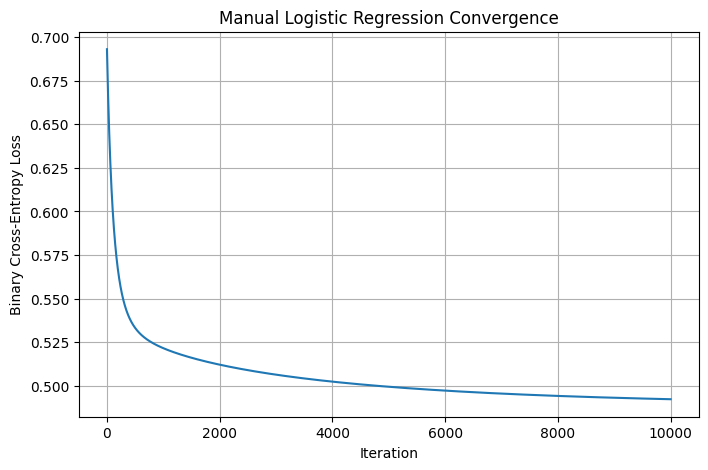

In [46]:
# Plot the training loss

plt.figure(figsize=(8, 5))

plt.plot(logistic_losses)

plt.xlabel("Iteration")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Manual Logistic Regression Convergence")

plt.grid(True)
plt.show()

In [48]:
# Inspect the loss at different stages

checkpoints = [
    100,
    500,
    1000,
    2000,
    5000,
    10000
]

print("Loss at selected iterations:")
print("-" * 35)

for iteration in checkpoints:
    print(
        f"Iteration {iteration:5d}: "
        f"{logistic_losses[iteration - 1]:.10f}"
    )

print("\nFinal loss:", logistic_losses[-1])

Loss at selected iterations:
-----------------------------------
Iteration   100: 0.6022077722
Iteration   500: 0.5331889991
Iteration  1000: 0.5215188338
Iteration  2000: 0.5120424793
Iteration  5000: 0.4993623885
Iteration 10000: 0.4922071008

Final loss: 0.49220710083750663


## 20. Learning-Rate Optimization

In [49]:
# ============================================================
# Learning Rate Experiment
# ============================================================

learning_rates = [0.01, 0.03, 0.05, 0.1]

learning_rate_results = []

for lr in learning_rates:

    start_time = time.perf_counter()

    test_weights, test_losses = fit_logistic_regression(
        X_manual_train_np,
        y_manual_clf_train,
        learning_rate=lr,
        n_iterations=10000
    )

    end_time = time.perf_counter()

    # Test-set predictions
    test_predictions = predict_logistic_class(
        X_manual_test_np,
        test_weights,
        threshold=0.5
    )

    # Metrics
    accuracy = manual_accuracy(
        y_manual_clf_test,
        test_predictions
    )

    precision = manual_precision(
        y_manual_clf_test,
        test_predictions
    )

    recall = manual_recall(
        y_manual_clf_test,
        test_predictions
    )

    f1 = manual_f1(
        y_manual_clf_test,
        test_predictions
    )

    learning_rate_results.append({
        "Learning Rate": lr,
        "Final Loss": test_losses[-1],
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Training Time (s)": end_time - start_time
    })


learning_rate_comparison = pd.DataFrame(
    learning_rate_results
)

display(learning_rate_comparison)

,Learning Rate,Final Loss,Accuracy,Precision,Recall,F1,Training Time (s)
0,0.01,0.492207,0.775,0.778281,0.971751,0.864322,3.425729
1,0.03,0.488283,0.775,0.783410,0.960452,0.862944,3.084027
2,0.05,0.487972,0.775,0.783410,0.960452,0.862944,4.410824
3,0.10,0.487896,0.775,0.783410,0.960452,0.862944,3.099914


## 21. Iteration and Convergence Tuning

In [50]:
# ============================================================
# Iteration Tuning with Learning Rate = 0.1
# ============================================================

iteration_values = [1000, 2000, 3000, 5000, 7500, 10000]

iteration_results = []

for n_iter in iteration_values:

    start_time = time.perf_counter()

    test_weights, test_losses = fit_logistic_regression(
        X_manual_train_np,
        y_manual_clf_train,
        learning_rate=0.1,
        n_iterations=n_iter
    )

    end_time = time.perf_counter()

    # Predictions
    test_predictions = predict_logistic_class(
        X_manual_test_np,
        test_weights,
        threshold=0.5
    )

    # Metrics
    accuracy = manual_accuracy(
        y_manual_clf_test,
        test_predictions
    )

    precision = manual_precision(
        y_manual_clf_test,
        test_predictions
    )

    recall = manual_recall(
        y_manual_clf_test,
        test_predictions
    )

    f1 = manual_f1(
        y_manual_clf_test,
        test_predictions
    )

    iteration_results.append({
        "Iterations": n_iter,
        "Final Loss": test_losses[-1],
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Training Time (s)": end_time - start_time
    })


iteration_comparison = pd.DataFrame(iteration_results)

display(iteration_comparison)

,Iterations,Final Loss,Accuracy,Precision,Recall,F1,Training Time (s)
0,1000,0.492209,0.775,0.778281,0.971751,0.864322,0.302155
1,2000,0.488947,0.775,0.780822,0.966102,0.863636,0.498127
2,3000,0.488283,0.775,0.783410,0.960452,0.862944,0.862154
3,5000,0.487972,0.775,0.783410,0.960452,0.862944,1.367281
4,7500,0.487906,0.775,0.783410,0.960452,0.862944,2.064831
5,10000,0.487896,0.775,0.783410,0.960452,0.862944,2.503681


## 22. Final Optimized Manual Logistic Regression

In [51]:
# ============================================================
# Final Optimized Manual Logistic Regression
# ============================================================

OPTIMIZED_LEARNING_RATE = 0.1
OPTIMIZED_ITERATIONS = 1000


# -------------------------
# Training
# -------------------------

start_train = time.perf_counter()

optimized_logistic_weights, optimized_logistic_losses = (
    fit_logistic_regression(
        X_manual_train_np,
        y_manual_clf_train,
        learning_rate=OPTIMIZED_LEARNING_RATE,
        n_iterations=OPTIMIZED_ITERATIONS
    )
)

end_train = time.perf_counter()

optimized_logistic_training_time = (
    end_train - start_train
)


# -------------------------
# Prediction
# -------------------------

start_predict = time.perf_counter()

optimized_clf_pred = predict_logistic_class(
    X_manual_test_np,
    optimized_logistic_weights,
    threshold=0.5
)

end_predict = time.perf_counter()

optimized_logistic_prediction_time = (
    end_predict - start_predict
)


# -------------------------
# Evaluation
# -------------------------

optimized_accuracy = manual_accuracy(
    y_manual_clf_test,
    optimized_clf_pred
)

optimized_precision = manual_precision(
    y_manual_clf_test,
    optimized_clf_pred
)

optimized_recall = manual_recall(
    y_manual_clf_test,
    optimized_clf_pred
)

optimized_f1 = manual_f1(
    y_manual_clf_test,
    optimized_clf_pred
)

optimized_final_loss = optimized_logistic_losses[-1]


# -------------------------
# Display Results
# -------------------------

print("Optimized From-Scratch Logistic Regression")
print("-" * 55)
print(f"Learning Rate : {OPTIMIZED_LEARNING_RATE}")
print(f"Iterations    : {OPTIMIZED_ITERATIONS}")
print(f"Final Loss    : {optimized_final_loss:.6f}")
print(f"Training Time : {optimized_logistic_training_time:.6f} seconds")
print(f"Prediction Time: {optimized_logistic_prediction_time:.6f} seconds")
print(f"Accuracy      : {optimized_accuracy:.6f}")
print(f"Precision     : {optimized_precision:.6f}")
print(f"Recall        : {optimized_recall:.6f}")
print(f"F1-score      : {optimized_f1:.6f}")

Optimized From-Scratch Logistic Regression
-------------------------------------------------------
Learning Rate : 0.1
Iterations    : 1000
Final Loss    : 0.492209
Training Time : 0.328139 seconds
Prediction Time: 0.000551 seconds
Accuracy      : 0.775000
Precision     : 0.778281
Recall        : 0.971751
F1-score      : 0.864322


## 23. Final Comparison — Regression

In [52]:
# ============================================================
# Final Regression Comparison
# ============================================================

final_regression_comparison = pd.DataFrame([
    {
        "Implementation": "Scikit-learn",
        "MAE": linear_mae,
        "RMSE": linear_rmse,
        "R2": linear_r2,
        "Training Time (s)": linear_training_time,
        "Prediction Time (s)": linear_prediction_time
    },
    {
        "Implementation": "From Scratch",
        "MAE": manual_linear_mae,
        "RMSE": manual_linear_rmse,
        "R2": manual_linear_r2,
        "Training Time (s)": manual_linear_training_time,
        "Prediction Time (s)": manual_linear_prediction_time
    }
])

display(final_regression_comparison.round(6))

,Implementation,MAE,RMSE,R2,Training Time (s),Prediction Time (s)
0,Scikit-learn,0.108453,0.148618,0.168168,0.065895,0.002638
1,From Scratch,0.108453,0.148618,0.168168,0.051759,0.000443


## 24. Final Comparison — Classification

In [53]:
# ============================================================
# Final Classification Comparison
# ============================================================

final_classification_comparison = pd.DataFrame([
    {
        "Implementation": "Scikit-learn",
        "Accuracy": logistic_accuracy,
        "Precision": logistic_precision,
        "Recall": logistic_recall,
        "F1": logistic_f1,
        "Training Time (s)": logistic_training_time,
        "Prediction Time (s)": logistic_prediction_time
    },
    {
        "Implementation": "From Scratch - Baseline",
        "Accuracy": manual_logistic_accuracy,
        "Precision": manual_logistic_precision,
        "Recall": manual_logistic_recall,
        "F1": manual_logistic_f1,
        "Training Time (s)": manual_logistic_training_time,
        "Prediction Time (s)": manual_logistic_prediction_time
    },
    {
        "Implementation": "From Scratch - Optimized",
        "Accuracy": optimized_accuracy,
        "Precision": optimized_precision,
        "Recall": optimized_recall,
        "F1": optimized_f1,
        "Training Time (s)": optimized_logistic_training_time,
        "Prediction Time (s)": optimized_logistic_prediction_time
    }
])

display(final_classification_comparison.round(6))

,Implementation,Accuracy,Precision,Recall,F1,Training Time (s),Prediction Time (s)
0,Scikit-learn,0.775,0.780822,0.966102,0.863636,0.263837,0.002480
1,From Scratch - Baseline,0.775,0.778281,0.971751,0.864322,2.755245,0.000331
2,From Scratch - Optimized,0.775,0.778281,0.971751,0.864322,0.328139,0.000551


## 25. Optimization Improvement

In [54]:
# ============================================================
# Optimization Improvement
# ============================================================

training_time_reduction = (
    (manual_logistic_training_time - optimized_logistic_training_time)
    / manual_logistic_training_time
) * 100

print("Optimization Improvement")
print("-" * 40)

print(
    f"Baseline training time  : "
    f"{manual_logistic_training_time:.6f} seconds"
)

print(
    f"Optimized training time : "
    f"{optimized_logistic_training_time:.6f} seconds"
)

print(
    f"Training time reduction : "
    f"{training_time_reduction:.2f}%"
)

print()

print(
    f"Baseline F1             : "
    f"{manual_logistic_f1:.6f}"
)

print(
    f"Optimized F1            : "
    f"{optimized_f1:.6f}"
)

Optimization Improvement
----------------------------------------
Baseline training time  : 2.755245 seconds
Optimized training time : 0.328139 seconds
Training time reduction : 88.09%

Baseline F1             : 0.864322
Optimized F1            : 0.864322


## 26. Final Observations

### Regression

The Scikit-learn and from-scratch Linear Regression implementations produced essentially identical results:

- MAE ≈ 0.108453
- RMSE ≈ 0.148618
- R² ≈ 0.168168

This occurs because both implementations use the same preprocessed features, the same train-test split, and the same least-squares optimization principle.

The from-scratch implementation used NumPy's Moore-Penrose pseudoinverse to calculate the regression coefficients.

### Classification

The Scikit-learn and from-scratch Logistic Regression implementations produced very similar classification performance.

The baseline from-scratch implementation achieved:

- Accuracy = 0.775000
- Precision = 0.778281
- Recall = 0.971751
- F1-score = 0.864322

The optimized from-scratch implementation maintained the same classification metrics while reducing the number of gradient-descent iterations from 10,000 to 1,000.

### Optimization

The baseline manual Logistic Regression used a learning rate of 0.01 and 10,000 iterations.

Experiments with different learning rates showed that a learning rate of 0.1 achieved a lower training loss.

Further experiments showed that increasing the number of iterations beyond 1,000 did not improve the test-set classification metrics. Therefore, the optimized configuration was selected as:

- Learning rate = 0.1
- Iterations = 1,000

This reduced the training computation substantially while preserving the observed test-set performance.

### Runtime

The from-scratch Linear Regression implementation was fast because the closed-form solution can be efficiently calculated using vectorized NumPy operations.

The initial from-scratch Logistic Regression was slower because gradient descent required many iterations. Reducing the number of iterations substantially reduced its training time.

The runtime measurements are specific to this execution environment and should not be interpreted as universal performance characteristics of NumPy versus Scikit-learn.

### Overall

The assignment demonstrates that the complete machine-learning workflow can be reproduced using NumPy and Pandas:

Raw Data
→ Preprocessing
→ Fixed Train-Test Split
→ Model Training
→ Prediction
→ Evaluation
→ Comparison
→ Optimization

The from-scratch implementation achieved predictive results close to the Scikit-learn implementation while also demonstrating the mathematical and computational steps underlying Linear Regression and Logistic Regression.

# 27. Final Results

In [55]:
# ============================================================
# FINAL RESULTS SUMMARY
# ============================================================

print("=" * 70)
print("FINAL RESULTS — DS605 LAB 5")
print("=" * 70)

print("\nREGRESSION")
print("-" * 70)

display(
    final_regression_comparison.round(6)
)

print("\nCLASSIFICATION")
print("-" * 70)

display(
    final_classification_comparison.round(6)
)

print("\nOPTIMIZATION")
print("-" * 70)

print(f"Baseline Learning Rate : 0.01")
print(f"Baseline Iterations    : 10,000")
print(f"Optimized Learning Rate: {OPTIMIZED_LEARNING_RATE}")
print(f"Optimized Iterations   : {OPTIMIZED_ITERATIONS}")
print(f"Training Time Reduction: {training_time_reduction:.2f}%")
print(f"Baseline F1            : {manual_logistic_f1:.6f}")
print(f"Optimized F1           : {optimized_f1:.6f}")

FINAL RESULTS — DS605 LAB 5

REGRESSION
----------------------------------------------------------------------


,Implementation,MAE,RMSE,R2,Training Time (s),Prediction Time (s)
0,Scikit-learn,0.108453,0.148618,0.168168,0.065895,0.002638
1,From Scratch,0.108453,0.148618,0.168168,0.051759,0.000443



CLASSIFICATION
----------------------------------------------------------------------


,Implementation,Accuracy,Precision,Recall,F1,Training Time (s),Prediction Time (s)
0,Scikit-learn,0.775,0.780822,0.966102,0.863636,0.263837,0.002480
1,From Scratch - Baseline,0.775,0.778281,0.971751,0.864322,2.755245,0.000331
2,From Scratch - Optimized,0.775,0.778281,0.971751,0.864322,0.328139,0.000551



OPTIMIZATION
----------------------------------------------------------------------
Baseline Learning Rate : 0.01
Baseline Iterations    : 10,000
Optimized Learning Rate: 0.1
Optimized Iterations   : 1000
Training Time Reduction: 88.09%
Baseline F1            : 0.864322
Optimized F1           : 0.864322


# 28. Conclusion

This assignment implemented the complete machine-learning workflow using both Scikit-learn and NumPy/Pandas from scratch.

## Regression

Linear Regression was implemented using the closed-form least-squares solution. The from-scratch implementation produced the same MAE, RMSE, and R² values as the Scikit-learn implementation:

- MAE = 0.108453
- RMSE = 0.148618
- R² = 0.168168

This demonstrates that the mathematical implementation correctly reproduces the regression model.

## Classification

Logistic Regression was implemented from scratch using:

- Sigmoid activation
- Binary cross-entropy loss
- Batch gradient descent
- Probability prediction
- 0.5 classification threshold
- Manually calculated accuracy, precision, recall, and F1-score

The from-scratch model achieved performance very close to the Scikit-learn model.

## Optimization

The baseline manual Logistic Regression required 10,000 iterations with a learning rate of 0.01.

After experimenting with the learning rate and number of iterations, the final manual model used:

- Learning rate = 0.1
- Iterations = 1,000

This reduced training time by approximately 88.09% compared with the baseline manual implementation while maintaining the same observed test-set F1-score of 0.864322.

## Overall Observation

The experiment demonstrates that the core machine-learning workflow can be implemented using only NumPy and Pandas. Scikit-learn provides optimized and convenient implementations, while the from-scratch implementation makes the underlying mathematical operations and optimization process explicit.

The final comparison was performed using the same train-test split and equivalent preprocessing, making the comparison reproducible and fair.